###### Loading data and dependecies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Set plot style
sns.set_theme(style="whitegrid")

# Load raw dataset
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


* Check Missing Values & Class Imbalance

Total Missing Values: 0
Legitimate Transactions (0): 284,315 (99.83%)
Fraudulent Transactions (1):  492 (0.17%)


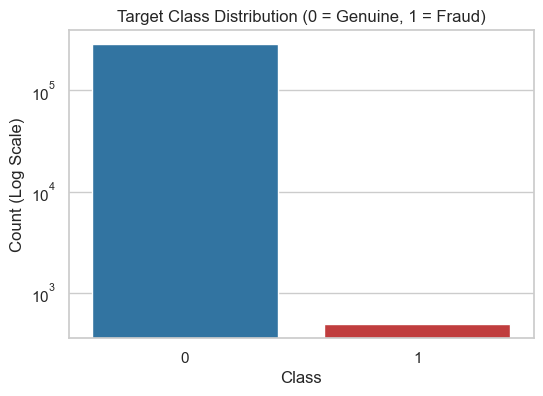

In [2]:
# Checking for null values
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

# Class distribution analysis
class_counts = df['Class'].value_counts()
fraud_pct = (class_counts[1] / len(df)) * 100

print(f"Legitimate Transactions (0): {class_counts[0]:,} ({100 - fraud_pct:.2f}%)")
print(f"Fraudulent Transactions (1):  {class_counts[1]:,} ({fraud_pct:.2f}%)")

# Plot Class Imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#1f77b4', '#d62728'], ax=ax)
plt.title('Target Class Distribution (0 = Genuine, 1 = Fraud)')
plt.yscale('log')  
plt.ylabel('Count (Log Scale)')
plt.show()

* Feature Scaling (Time & Amount)

In [3]:
scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Dropping raw unscaled features
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reordering columns so 'Class' remains at the end
scaled_amount = df.pop('scaled_amount')
scaled_time = df.pop('scaled_time')
target_class = df.pop('Class')

df['scaled_amount'] = scaled_amount
df['scaled_time'] = scaled_time
df['Class'] = target_class

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,-0.994983,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,-0.994983,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,-0.994972,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,-0.994972,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,-0.994960,0


* Exporting Preprocessed Dataset

In [ ]:
import os

output_path = '../data/processed/creditcard_scaled.csv'

# Saving as CSV without index
df.to_csv(output_path, index=False)
print(f"Successfully processed and saved dataset to '{output_path}'!")